# The Exchange-Listing-Pop — a quantitative teardown 🔬
### BTC-adjusted clustered CARs on 129 Coinbase listings · random-date placebo · month-cluster robustness · the 2022 roadmap natural experiment · cost × borrow sweep on the fade · a synthetic faithful-engine control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Gone_before_you_can_act%3F: Confirmed](https://img.shields.io/badge/Gone_before_you_can_act%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The "Coinbase effect" is folklore with a criminal case attached (*U.S. v. Wahi*, 2022) — so the job is to measure it honestly: venue-API event dates, market-adjusted CARs, cluster-aware inference, and the only executable version of the trade.

> ⚠️ **Data note.** Day 0 = first Coinbase Exchange **USD-product** daily candle (Coinbase's own API, hardcoded table with a per-row venue price-agreement check). Prices: Binance USDT klines (the coins trade there ≥ 60 days before every event); abnormal = coin log return − BTC log return. **Survivorship named:** only Coinbase-served candle histories enter; five 2018–20 USDC-quoted books (BAT, ZEC, CVC, DNT, MANA) are excluded as mis-datable. Numbers in [`docs/results.md`](../docs/results.md) (fingerprint `f6a046325f17`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from exchange_listing_pop import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    EV = data.events_frame()
    EV = EV[EV["coin"].isin(PX.columns)].reset_index(drop=True)
    ABN = st.abnormal_returns(PX)
else:
    PX = EV = ABN = None
print("real cache present:", HAVE_REAL,
      "| events:", (0 if EV is None else len(EV)),
      "| panel:", (None if PX is None else PX.shape))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2017-08-17', 'end': '2026-07-02', 'years': 8.9, 'days': 3242, 'n_coins': 134, 'n_events': 129, 'n_clusters': 95, 'n_pre': 56, 'n_post': 73, 'windows': [('early run-up [-20..-6]', -20, -6, 2.4, 2.43, 1.25), ('run-up [-5..-1]', -5, -1, 10.23, 10.77, 5.91), ('listing day [0]', 0, 0, 0.77, 0.77, 0.82), ('THE POP [-5..0]', -5, 0, 11.0, 11.63, 5.74), ('post [+1..+5]', 1, 5, -6.14, -5.96, -3.93), ('THE FADE [+1..+30]', 1, 30, -17.45, -16.02, -5.73)], 'pop': {'car': 11.0, 't': 5.74, 't_month': 5.3, 'med': 7.11, 'share_pos': 76, 'obs_event': 14.6, 'welch': 6.92, 'p': '< 0.0005', 'n_pooled': 188947}, 'fade': {'car': -17.45, 't': -5.73, 't_month': -4.96, 'med': -17.97, 'share_pos': 19, 'obs_event': -16.79, 'welch': -4.38, 'p': '< 0.0005', 'n_pooled': 185676}, 'era': {'pre_pop': 17.17, 'pre_pop_t': 5.52, 'post_pop': 7.06, 'post_pop_t': 3.06, 'pre_fade': -16.98, 'pre_fade_t': -3.95, 'post_fade': -17.76, 'post_fade_t': -4.23, 'diff_welch': 2.61, 'n_pre_cl': 37, 'n_post_cl': 58}, 'long_tr': [(5, 10, -4.58, -2.59, -5.03, -2.84, 19), (5, 25, -4.58, -2.59, -5.63, -3.17, 17), (5, 50, -4.58, -2.59, -6.63, -3.74, 14), (30, 10, -11.97, -3.92, -12.61, -4.13, 18), (30, 25, -11.97, -3.92, -13.21, -4.33, 18), (30, 50, -11.97, -3.92, -14.21, -4.66, 18)], 'short_tr': [(10, 11.97, 3.92, 10.74, 3.52, 79), (25, 11.97, 3.92, 10.14, 3.32, 76), (50, 11.97, 3.92, 9.14, 3.0, 75)], 'borrow': [(10, 10.14, 3.32, 76), (50, 6.86, 2.25, 74), (100, 2.75, 0.9, 67)], 'gaps': [('MATIC', '2021-03-09', '2021-03-11', 2), ('ADA', '2021-03-16', '2021-03-18', 2), ('DOGE', '2021-06-01', '2021-06-03', 2), ('SOL', '2021-05-20', '2021-06-17', 28)], 'syn': [(0.0, 0.0, 0.41, 0.21, 2.89, 0.7), (15.0, 10.0, 15.41, 7.71, -7.11, -1.73)], 'fingerprint': 'f6a046325f17'}


real cache present: True | events: 129 | panel: (3242, 135)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Pop CAR[−5..0] **+11.00%** (cluster *t* = **+5.74**, month-cluster *t* = +5.30, placebo *p* < 0.0005); fade CAR[+1..+30] **-17.45%** (*t* = **-5.73**). |
| **Tradability** | `FRAGILE` | Follower long: **-13.21% net** (*t* = -4.33). Fade short: **+10.14% net** (*t* = +3.32) at 10%/yr borrow — **+2.75%** (*t* = +0.90) at 100%/yr. Borrow-bound, short-only. |
| **Gone before you can act?** | `CONFIRMED` | Run-up [−5..−1] **+10.23%** (*t* = +5.91) vs listing day **+0.77%** (*t* = +0.82); roadmap era halved the pop (Welch *t* = +2.61). |

> 💡 In plain words: the legend is true, the hangover is bigger than the party, and the party is over before the doors open.

## 1 · The claim, steelmanned

Let $r_{i,t}$ be coin $i$'s daily log return and $m_t$ BTC's. The abnormal return is $a_{i,t} = r_{i,t} - m_t$ (market model, $\beta = 1$ — the standard crypto event-study adjustment) and the CAR over event offsets $[a..b]$ around listing day $\tau_i$ is

$$\mathrm{CAR}_i(a,b) = \sum_{k=a}^{b} a_{i,\tau_i+k}.$$

- **H₁ (pop).** $\overline{\mathrm{CAR}}(-5,0) > 0$ — the coin outruns BTC into the listing.
- **H₂ (give-back).** $\overline{\mathrm{CAR}}(+1,+30) < 0$ — and gives it back after.
- **H₃ (tradability).** A follower entering at the day-0 close (ONE lag) captures something net of costs — long the pop's continuation, or short the fade.

Same-day listings (Coinbase announces several assets per post) are **one news draw**: the primary unit is the *listing-day cluster* (95 clusters for 129 events).

## 2 · So what? — what rides on each answer

Three honesty problems sit on top of a naive event average: **(a) market timing** — 2021 listings landed in a bull market, so raw returns overstate the event (hence BTC-adjustment); **(b) cross-sectional clustering** — multi-asset announcements are correlated draws (hence day-clusters, and a month-cluster robustness); **(c) the counterfactual** — maybe these coins outrun BTC around *any* date (hence a random-date placebo on the same coins). Tradability then has exactly one honest version: the **day-0 close** is the first fill a non-insider can get; every window before that is someone else's money.

## 3 · How we'd know — the protocol

- **Events.** 129 listings 2019–2026 (hardcoded, per-row venue-ratio check; 95 same-day clusters; 56 events pre-roadmap / 73 after 2022-04-28).
- **Tape.** Binance USDT daily klines, 3,242 days × 134 coins + BTC, 2017-08-17 → 2026-07-02 (8.9 yrs).
- **Windows.** [−20..−6], [−5..−1], [0], [−5..0] (pop), [+1..+5], [+1..+30] (fade).
- **Primary null.** One-sample *t* on per-cluster CARs; month-cluster and hit-rate robustness; Welch *t* + empirical *p* vs a same-coin random-date placebo (2,000 draws, 20-seed stable — canonical numbers from `docs/results.md`).
- **Costs.** 10/25/50 bps one-way per leg; shorts pay borrow 10%/yr (alt) / 3%/yr (BTC), sensitivity to 100%/yr.
- **Control.** Deterministic synthetic world with plantable pop (−2..0) and fade (+1..+20); the null must stay quiet.

## 4 · The teardown

### 4a · The event-time CAR path — the whole story in one curve

Mean cumulative abnormal return by event day, with the per-event spread behind it.

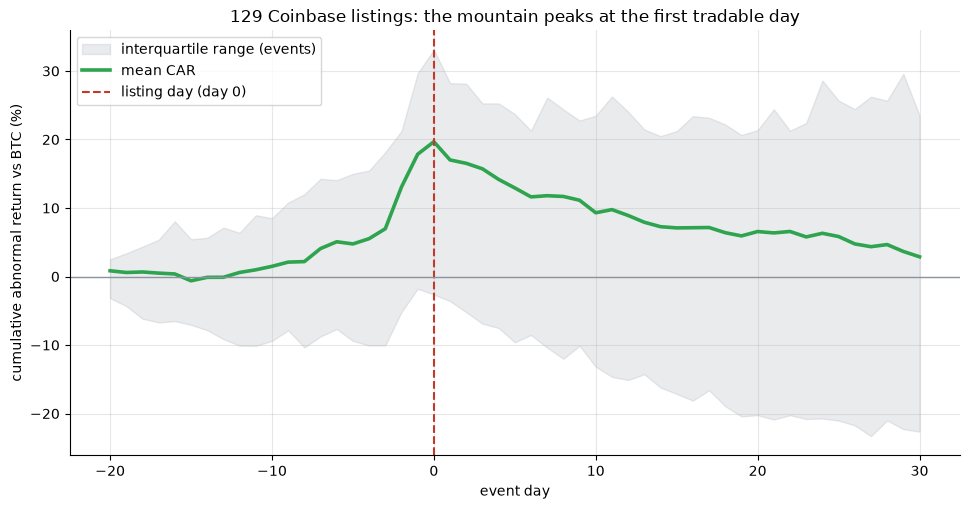

mean CAR at day 0: +19.67%  at +30: +2.88%  (n=129 events)


In [2]:
if HAVE_REAL:
    M = st.event_matrix(ABN, EV, -20, 30)
    paths = M.cumsum() * 100
    mean_path = paths.mean(axis=1)
    lo, hi = paths.quantile(.25, axis=1), paths.quantile(.75, axis=1)
    fig, ax = plt.subplots(figsize=(9.8, 5.2))
    ax.fill_between(paths.index, lo, hi, alpha=.18, color=GREY, label='interquartile range (events)')
    ax.plot(mean_path.index, mean_path.values, lw=2.6, color=GREEN, label='mean CAR')
    ax.axvline(0, ls='--', c=RED, lw=1.5, label='listing day (day 0)')
    ax.axhline(0, c=GREY, lw=1)
    ax.set_xlabel('event day'); ax.set_ylabel('cumulative abnormal return vs BTC (%)')
    ax.set_title('129 Coinbase listings: the mountain peaks at the first tradable day')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'mean CAR at day 0: {mean_path.loc[0]:+.2f}%  at +30: {mean_path.loc[30]:+.2f}%  (n={M.shape[1]} events)')
else:
    print('cache missing - see R for canonical numbers'); print(R['windows'])

### 4b · Windows, clustered *t*, placebo

Cluster-level one-sample *t* per window; the placebo pits the event CARs against the same coins on random non-event dates (≥ 90 days away). The in-notebook placebo uses **300 draws for the picture**; canonical inference (2,000 draws, 20 seeds) is quoted from `docs/results.md`.

window                     mean CAR   cluster t
  early run-up [-20..-6]      +2.40%    +1.25   (n=95 clusters)
  run-up [-5..-1]            +10.23%    +5.91   (n=95 clusters)


  listing day [0]             +0.77%    +0.82   (n=95 clusters)
  THE POP [-5..0]            +11.00%    +5.74   (n=95 clusters)
  post [+1..+5]               -6.14%    -3.93   (n=95 clusters)


  THE FADE [+1..+30]         -17.45%    -5.73   (n=95 clusters)


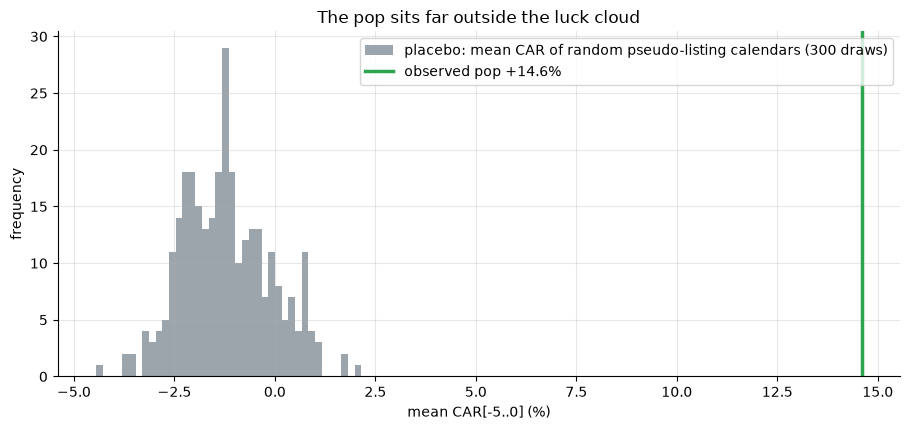

placebo (300 draws): p = 0.0000; canonical 2,000-draw, 20-seed: p < 0.0005


In [3]:
if HAVE_REAL:
    print('window                     mean CAR   cluster t')
    for lab, a, b, *_ in R['windows']:
        s = st.window_summary(ABN, EV, a, b)
        print(f"  {lab:<24} {s['mean_car']*100:+8.2f}%   {s['t']:+6.2f}   (n={s['n_clusters']} clusters)")
    pl = st.placebo_pvalue(ABN, EV, -5, 0, n_draws=300, seed=636, side='greater')
    fig, ax = plt.subplots(figsize=(9.2, 4.4))
    ax.hist(pl['draws'] * 100, bins=40, color=GREY, alpha=.85,
            label='placebo: mean CAR of random pseudo-listing calendars (300 draws)')
    ax.axvline(pl['obs'] * 100, c=GREEN, lw=2.5, label=f"observed pop {pl['obs']*100:+.1f}%")
    ax.set_xlabel('mean CAR[-5..0] (%)'); ax.set_ylabel('frequency')
    ax.set_title('The pop sits far outside the luck cloud')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"placebo (300 draws): p = {pl['p']:.4f}; canonical 2,000-draw, 20-seed: p {R['pop']['p']}")
else:
    print(R['pop'], R['fade'])

> 💡 In plain words: random weeks on these same coins produce a mean "pop" near **zero**; the observed **+14.6%** (event-level) is beyond every placebo draw (canonical Welch *t* = +6.92 vs 188,947 placebo windows, *p* < 0.0005; fade Welch *t* = -4.38, *p* < 0.0005). Robustness: month-clustered *t* = +5.30 / -4.96, median cluster pop +7.1%, 76% of clusters positive — not an outlier, not a 2021 artefact.

### 4c · The 2022 roadmap — a natural experiment on information leakage

2022-04-28: after the DOJ front-running case, Coinbase began pre-announcing listings on a public roadmap (weeks of notice instead of 2 days). If the pop is announcement-driven information, front-loading the news should **flatten and spread** it.

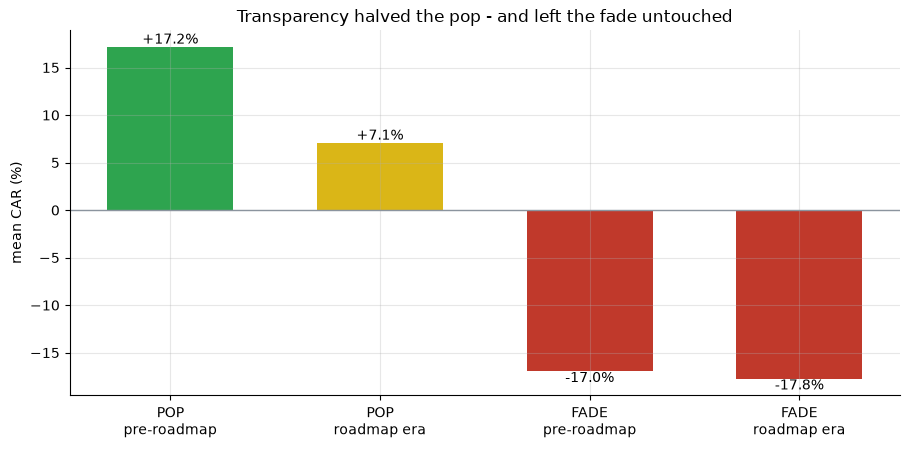

pop pre/post: +17.2% / +7.1%  fade pre/post: -17.0% / -17.8%


In [4]:
if HAVE_REAL:
    ev_pre = EV[EV['day0'] < data.ROADMAP_ERA]; ev_post = EV[EV['day0'] >= data.ROADMAP_ERA]
    pp = st.window_summary(ABN, ev_pre, -5, 0); qq = st.window_summary(ABN, ev_post, -5, 0)
    fp = st.window_summary(ABN, ev_pre, 1, 30); fq = st.window_summary(ABN, ev_post, 1, 30)
    vals = [pp['mean_car']*100, qq['mean_car']*100, fp['mean_car']*100, fq['mean_car']*100]
else:
    vals = [R['era']['pre_pop'], R['era']['post_pop'], R['era']['pre_fade'], R['era']['post_fade']]
labels = ['POP\npre-roadmap', 'POP\nroadmap era', 'FADE\npre-roadmap', 'FADE\nroadmap era']
fig, ax = plt.subplots(figsize=(9.2, 4.6))
ax.bar(labels, vals, color=[GREEN, AMBER, RED, RED], width=.6)
for i, v in enumerate(vals): ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom' if v > 0 else 'top')
ax.axhline(0, c=GREY, lw=1); ax.set_ylabel('mean CAR (%)')
ax.set_title('Transparency halved the pop - and left the fade untouched')
plt.tight_layout(); plt.show()
print('pop pre/post:', f"{vals[0]:+.1f}% / {vals[1]:+.1f}%", ' fade pre/post:', f"{vals[2]:+.1f}% / {vals[3]:+.1f}%")

> 💡 In plain words: pre-roadmap pop **+17.17%** (*t* = +5.52) vs roadmap-era **+7.06%** (*t* = +3.06) — difference Welch *t* = **+2.61**. Publishing the news weeks early let it leak into a long dribble ([−20..−6] is only +2.4%, *t* = 1.25 — spread thin, it stops being measurable). The **fade didn't budge** (-16.98% → -17.76%): attention decay doesn't care about disclosure policy. Textbook McLean-Pontiff, in fast-forward.

### 4d · Tradability — the one executable version, costed

Enter at the **day-0 close** (one lag), exit at +5/+30; hedged with BTC; one-way costs per leg; shorts pay borrow. The long rides the folklore; the short fades it.

LONG the listing (hedged short-BTC):
  + 5d   10bps: net   -5.03%  t=-2.84  hit 19%


  + 5d   25bps: net   -5.63%  t=-3.17  hit 17%


  + 5d   50bps: net   -6.63%  t=-3.74  hit 14%
  +30d   10bps: net  -12.61%  t=-4.13  hit 18%


  +30d   25bps: net  -13.21%  t=-4.33  hit 18%
  +30d   50bps: net  -14.21%  t=-4.66  hit 18%
SHORT the listing / long BTC (borrow sweep, 25 bps, +30d):


  borrow   10%/yr: net  +10.14%  t=+3.32  hit 76%
  borrow   50%/yr: net   +6.86%  t=+2.25  hit 74%


  borrow  100%/yr: net   +2.75%  t=+0.90  hit 67%


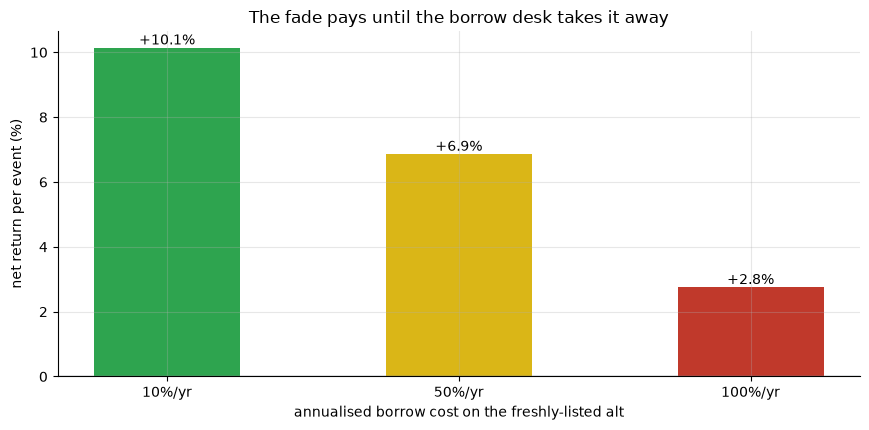

In [5]:
if HAVE_REAL:
    print('LONG the listing (hedged short-BTC):')
    for h in (5, 30):
        for cb in (10., 25., 50.):
            s = st.trade_summary(st.follower_trade(PX, EV, hold=h, cost_bps=cb, hedged=True))
            print(f'  +{h:>2}d {cb:>4.0f}bps: net {s["net_pct"]:+7.2f}%  t={s["t_net"]:+5.2f}  hit {s["hit"]*100:.0f}%')
    print('SHORT the listing / long BTC (borrow sweep, 25 bps, +30d):')
    for br in (0.10, 0.50, 1.00):
        s = st.trade_summary(st.follower_trade(PX, EV, hold=30, cost_bps=25., hedged=True, side='short', borrow_alt=br))
        print(f'  borrow {br*100:>4.0f}%/yr: net {s["net_pct"]:+7.2f}%  t={s["t_net"]:+5.2f}  hit {s["hit"]*100:.0f}%')
borrows = [b[0] for b in R['borrow']]; nets = [b[1] for b in R['borrow']]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar([f'{b}%/yr' for b in borrows], nets, color=[GREEN, AMBER, RED], width=.5)
for i, v in enumerate(nets): ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom')
ax.axhline(0, c=GREY, lw=1)
ax.set_xlabel('annualised borrow cost on the freshly-listed alt')
ax.set_ylabel('net return per event (%)')
ax.set_title('The fade pays until the borrow desk takes it away')
plt.tight_layout(); plt.show()

> 💡 In plain words: the *buy-the-news* trade loses **-13.2% net** per event (*t* = -4.33, hit rate 18%) — it is not merely dead, it is a donation. The **fade** nets **+10.1%** (*t* = +3.32, hit 76%) at 10%/yr borrow and survives 50%/yr (+6.9%, *t* = +2.25) — but at 100%/yr it's noise (+2.8%, *t* = +0.90). Fresh listings are exactly where spot borrow is scarce, rationed and repriced against you — the constraint is the borrow desk, not the signal. Hence **FRAGILE**.

### 4e · Faithful-engine & power control — we know the truth here

Deterministic synthetic world, staggered pseudo-listings, a plantable pop and fade. The null must stay quiet; the planted effect must be recovered at its true size.

planted pop=  0.0% fade=  0.0%: CAR[-5..0]= +0.41% (t +0.21)  CAR[+1..+30]= +2.89% (t +0.70)
planted pop= 15.0% fade= 10.0%: CAR[-5..0]=+15.41% (t +7.71)  CAR[+1..+30]= -7.11% (t -1.73)


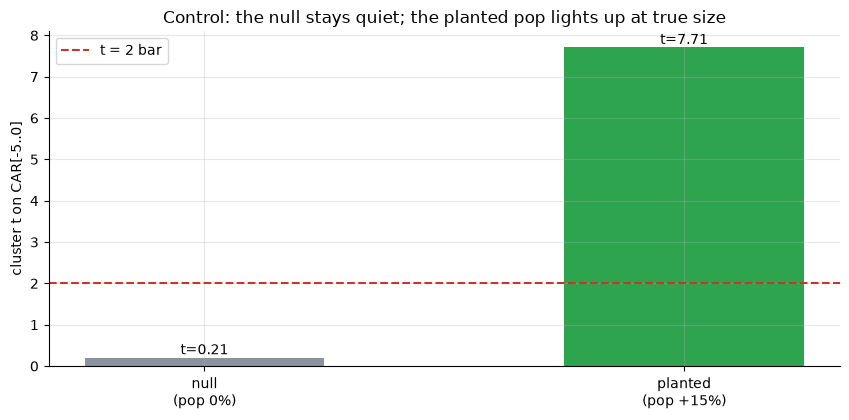

In [6]:
res = []
for pop, fade in [(0.0, 0.0), (0.15, 0.10)]:
    spx, sev = data.synthetic_world(pop=pop, fade=fade, seed=636)
    sabn = st.abnormal_returns(spx)
    sp = st.window_summary(sabn, sev, -5, 0); sf = st.window_summary(sabn, sev, 1, 30)
    res.append((pop, sp['mean_car']*100, sp['t'], sf['mean_car']*100, sf['t']))
    print(f'planted pop={pop*100:5.1f}% fade={fade*100:5.1f}%: '
          f"CAR[-5..0]={sp['mean_car']*100:+6.2f}% (t{sp['t']:+6.2f})  "
          f"CAR[+1..+30]={sf['mean_car']*100:+6.2f}% (t{sf['t']:+6.2f})")
fig, ax = plt.subplots(figsize=(8.6, 4.3))
labels = ['null\n(pop 0%)', 'planted\n(pop +15%)']
ax.bar(labels, [r[2] for r in res], color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(res): ax.annotate(f't={r[2]:.2f}', (i, r[2]), ha='center', va='bottom')
ax.set_ylabel('cluster t on CAR[-5..0]')
ax.set_title('Control: the null stays quiet; the planted pop lights up at true size')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: with nothing planted the machinery reads *t* = +0.21 (it cannot conjure a pop from noise); a planted +15% pop is recovered at +15.41% (*t* = +7.71). The real-tape *t* = +5.74 is therefore the genuine article. *(Machinery proof only — never cited in support of the stamps.)*

## 5 · The verdict

- **Signal `REAL`** — pop CAR[−5..0] **+11.00%** (cluster *t* = +5.74, month-cluster +5.30, placebo *p* < 0.0005 across 20 seeds) and fade CAR[+1..+30] **-17.45%** (*t* = -5.73, month-cluster -4.96) on 129 events / 95 clusters. Both halves of the folklore clear the bar. Survivorship named.
- **Tradability `FRAGILE`** — the follower long is **-13.21% net** (*t* = -4.33); the fade short is **+10.14% net** (*t* = +3.32) at 10%/yr borrow, +6.86% at 50%/yr, **+2.75% (t = +0.90)** at 100%/yr. Short-only, borrow-bound, per-event capacity tiny. Not INVESTABLE.
- **Gone before you can act? `CONFIRMED`** — [−5..−1] carries +10.23 pp (*t* = +5.91) vs the listing day's +0.77% (*t* = +0.82); documented announcement→trade gaps are 2 days (Pro era) to weeks (roadmap era); the roadmap halved the pop (Welch *t* = +2.61).

## 6 · Going further

- **The decay is the lesson.** Announcement effects migrate up the information chain: blog-post era → 2-day pop at the announcement; roadmap era → half the pop, leaked over weeks; *Wahi* era → some of it traded before any public post. The equity ancestor ([249-index-inclusion](../../249-index-inclusion/)) completed the same arc in ~20 years; crypto did it in three.
- **The fade is an attention story, not a listing story.** It survives the policy change because it's driven by post-listing attention decay and early-holder distribution — which suggests it generalises to other attention spikes (new perp listings, trending pairs) and will persist until borrow supply on fresh listings industrialises.
- **Refinements that would sharpen it:** per-event beta estimation (we fix β = 1), volume-conditioned fades, and an announcement-timestamped intraday version — the daily tape necessarily smears the first minutes after the blog post.

*The reproducible core is offline and deterministic; canonical numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*